In [ ]:
from lib import *
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

gatherer = Gatherer()
pd.set_option('display.max_rows', None)
df = gatherer.get_survey_df()
df2 = gatherer.get_audio_video_features_df()
df.head()

,user_id,partner_id,convo_id,date,survey_duration_in_seconds,time_zone,pre_affect,pre_arousal,technical_quality,conv_length,...,my_conscientious,my_neurotic,my_open,your_extraversion,your_agreeable,your_conscientious,your_neurotic,your_open,who_i_talked_to_most_past24,most_common_format_past24
0,5a73899f9cdd1800017786f0,5fa072f4f4aa580b63834357,0020a0c5-1658-4747-99c1-2839e736b481,2020-11-10,4115,6.0,5.0,4.0,1.0,45.0,...,4.000000,4.000000,3.666667,4.333333,4.000000,4.666667,3.000000,4.666667,NaN,NaN
1,5fa072f4f4aa580b63834357,5a73899f9cdd1800017786f0,0020a0c5-1658-4747-99c1-2839e736b481,2020-11-10,3949,6.0,7.0,6.0,1.0,43.0,...,2.333333,4.333333,5.000000,4.000000,4.000000,4.333333,2.666667,3.666667,NaN,NaN
2,5f482b0da1cde52de45f174c,5f57120cba207c18f058a62b,002d68da-7738-4177-89d9-d72ae803e0e4,2020-11-15,3293,8.0,7.0,6.0,1.0,34.0,...,2.666667,4.666667,4.333333,4.333333,3.666667,2.666667,4.000000,4.000000,NaN,NaN
3,5f57120cba207c18f058a62b,5f482b0da1cde52de45f174c,002d68da-7738-4177-89d9-d72ae803e0e4,2020-11-15,4393,5.0,7.0,5.0,1.0,34.0,...,2.666667,5.000000,4.666667,3.000000,4.333333,5.000000,1.666667,4.666667,NaN,NaN
4,5d510396f6725b001a4fc025,5dd5bc3bd5cef8000b9861d5,00411458-8275-4b92-a000-d52187f03604,2020-01-09,3215,6.0,6.0,4.0,2.0,35.0,...,2.333333,4.333333,2.000000,5.000000,4.333333,3.666667,2.000000,3.000000,NaN,NaN


In [ ]:
df2.columns.tolist()
df2.isnull().sum()

timedelta                    0
user_id                      0
f0                     3848222
intensity              1040928
jitter                 3848282
log_energy             1040928
mfcc_0                 1040928
mfcc_1                 2210594
mfcc_10                2210594
mfcc_11                2210594
mfcc_12                2210594
mfcc_13                2210594
mfcc_14                2210594
mfcc_15                2210594
mfcc_16                2210594
mfcc_17                2210594
mfcc_18                2210594
mfcc_19                2210594
mfcc_2                 2210594
mfcc_3                 2210594
mfcc_4                 2210594
mfcc_5                 2210594
mfcc_6                 2210594
mfcc_7                 2210594
mfcc_8                 2210594
mfcc_9                 2210594
onset_strength         2219214
poly_features_0        1582442
poly_features_1        1582442
shimmer                3852173
spectral_bandwidth     1582442
spectral_centroid      1582442
spectral

In [ ]:
emotion_cols = [
    'prob_face_anger', 'prob_face_contempt', 'prob_face_disgust', 
    'prob_face_fear', 'prob_face_happiness', 'prob_face_neutral', 
    'prob_face_sadness', 'prob_face_surprise', 'smile'
]

null_pattern = df2[emotion_cols].isnull().T
grouped = null_pattern.groupby(null_pattern.apply(tuple, axis=1))
print("กลุ่ม Column ที่มี Pattern Null เหมือนกัน")
for i, (pattern, group) in enumerate(grouped, 1):
    cols = group.index.tolist()
    print(f"กลุ่มที่ {i}: {cols}")

--- กลุ่ม Column ที่มี Pattern Null เหมือนกันเป๊ะ ---
กลุ่มที่ 1: ['smile']
กลุ่มที่ 2: ['prob_face_anger', 'prob_face_contempt', 'prob_face_disgust', 'prob_face_fear', 'prob_face_happiness', 'prob_face_neutral', 'prob_face_sadness', 'prob_face_surprise']


In [ ]:
print("--- Check Null Counts ---")
print(df2[['jitter', 'intensity', 'is_speaking']].isnull().sum())

--- Check Null Counts ---
jitter         3848282
intensity      1040928
is_speaking          0
dtype: int64


In [6]:
feature_cols = [
    'prob_face_anger', 'prob_face_contempt', 'prob_face_disgust', 
    'prob_face_fear', 'prob_face_happiness', 'prob_face_neutral', 
    'prob_face_sadness', 'prob_face_surprise',
    'jitter', 'intensity', 'f0' , 'smile'
]

speaking_df = df2[df2['is_speaking'] == True]

user_avg_speaking_df = speaking_df.groupby(['convo_id', 'user_id'])[feature_cols].mean()

In [ ]:
user_avg_speaking_df.to_csv('user_avg_speaking_result2.csv', encoding='utf-8-sig')
user_avg_speaking_df.head()

In [58]:
# 1. คำนวณ Correlation ทั้งหมด
corr_matrix = df.select_dtypes(include=['number']).corr()

# 2. ดึงเฉพาะคอลัมน์ how_enjoyable และตัดตัวมันเองทิ้ง
target_corr = corr_matrix['how_enjoyable'].drop('how_enjoyable')

# 3. เรียงลำดับตามความแรง (Absolute Value) จากมากไปน้อย
top_5_features = target_corr.loc[target_corr.abs().sort_values(ascending=False).index[:5]]

print("Top 5 Features correlating with 'how_enjoyable':")
print(top_5_features)

Top 5 Features correlating with 'how_enjoyable':
i_like_you                    0.843695
overall_affect                0.783228
end_affect                    0.777563
affect                        0.766741
i_felt_close_to_my_partner    0.761905
Name: how_enjoyable, dtype: float64


จำนวนแถวที่ how_enjoyable หายไป: 55
i_like_you                    55
overall_affect                55
end_affect                    55
affect                        55
i_felt_close_to_my_partner    55
dtype: int64
                            i_like_you  overall_affect  end_affect    affect  \
i_like_you                    1.000000        0.702965    0.706071  0.688865   
overall_affect                0.702965        1.000000    0.828753  0.828629   
end_affect                    0.706071        0.828753    1.000000  0.807202   
affect                        0.688865        0.828629    0.807202  1.000000   
i_felt_close_to_my_partner    0.736729        0.670628    0.654148  0.647994   

                            i_felt_close_to_my_partner  
i_like_you                                    0.736729  
overall_affect                                0.670628  
end_affect                                    0.654148  
affect                                        0.647994  
i_felt_close_to_my_p

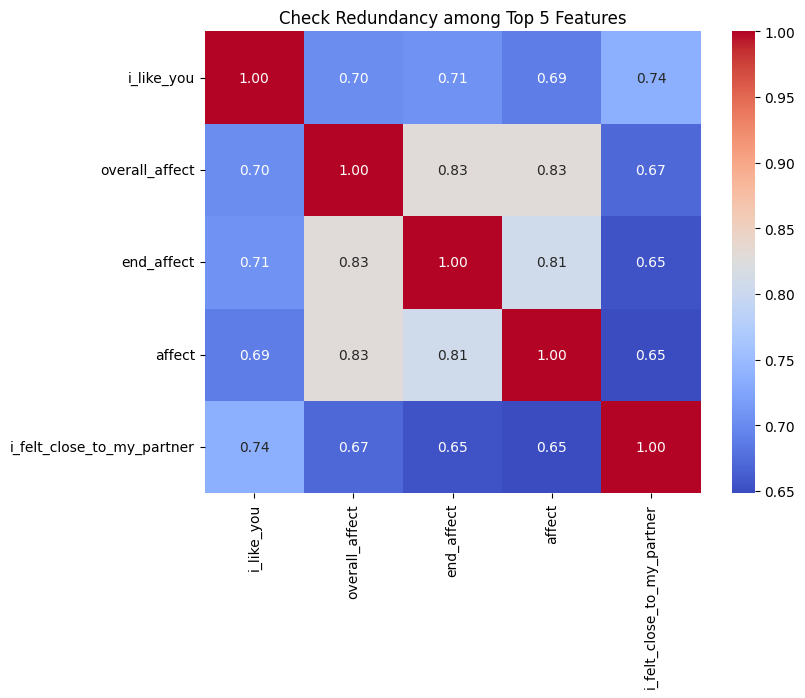

In [ ]:
features = ['i_like_you', 'overall_affect', 'end_affect', 'affect', 'i_felt_close_to_my_partner']

missing_rows = df[df['how_enjoyable'].isnull()]

print(f"จำนวนแถวที่ how_enjoyable หายไป: {len(missing_rows)}")
print(missing_rows[features].isnull().sum())

corr_matrix = df[features].corr()
print(corr_matrix)


plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Check Redundancy among Top 5 Features")
plt.show()

In [6]:
# สร้าง column ใหม่ โดยเฉลี่ยคะแนน how_enjoyable ตามกลุ่ม convo_id
df['quality_convo'] = df.groupby('convo_id')['how_enjoyable'].transform('mean')

# ลองเช็กผลลัพธ์
print(df[['convo_id', 'user_id', 'how_enjoyable', 'quality_convo']].head(6))

                               convo_id                   user_id  \
0  0020a0c5-1658-4747-99c1-2839e736b481  5a73899f9cdd1800017786f0   
1  0020a0c5-1658-4747-99c1-2839e736b481  5fa072f4f4aa580b63834357   
2  002d68da-7738-4177-89d9-d72ae803e0e4  5f482b0da1cde52de45f174c   
3  002d68da-7738-4177-89d9-d72ae803e0e4  5f57120cba207c18f058a62b   
4  00411458-8275-4b92-a000-d52187f03604  5d510396f6725b001a4fc025   
5  00411458-8275-4b92-a000-d52187f03604  5dd5bc3bd5cef8000b9861d5   

   how_enjoyable  quality_convo  
0            8.0            8.5  
1            9.0            8.5  
2            9.0            8.0  
3            7.0            8.0  
4            8.0            7.5  
5            7.0            7.5  


In [8]:
# เซฟเป็นไฟล์ CSV
df[['convo_id', 'user_id', 'how_enjoyable', 'quality_convo']].to_csv('final_please.csv', index=False, encoding='utf-8-sig')

In [7]:
df['how_enjoyable'].value_counts(dropna = False)

how_enjoyable
9.0    930
8.0    837
7.0    772
6.0    373
5.0    181
4.0     86
NaN     55
3.0     44
1.0     19
2.0     15
Name: count, dtype: int64

In [6]:
import numpy as np

df['quality_convo'] = df['quality_convo'].fillna(-1)
df['how_enjoyable'] = df['how_enjoyable'].fillna(-1)

In [6]:
# Group by user_id และหาค่าเฉลี่ยของ 2 คอลัมน์ที่ต้องการ
user_grouped_df = df.groupby('user_id')[['how_enjoyable', 'quality_convo']].mean().reset_index()

In [8]:
user_grouped_df = user_grouped_df.fillna(-1)

# Reset index เพื่อให้ user_id กลับมาเป็น Column ปกติ
user_grouped_df = user_grouped_df.reset_index()

In [15]:
# ลบคอลัมน์ชื่อ 'index' ทิ้ง
user_grouped_df = user_grouped_df.drop(columns=['index'])

# ลองเช็กดูอีกรอบ
print(user_grouped_df.head())

                    user_id  how_enjoyable  quality_convo
0  53979923fdf99b1ccc3f11f6            8.0       8.250000
1  555527dafdf99b16a75afd54            9.0       8.500000
2  558823c2fdf99b318cb4224b            7.0       6.000000
3  558a0bc6fdf99b2d7699a94c            9.0       8.500000
4  558a327cfdf99b2d75651681            6.5       6.666667


In [18]:
# ตอนบันทึกไฟล์ ไม่ต้องเอาลำดับตัวเลข (Index) ไปด้วย
user_grouped_df.to_csv('user_conversation_enjoy.csv', index=False, encoding='utf-8-sig')

1882    8.5
2770    8.0
Name: quality_convo, dtype: float64

In [5]:
df[['how_enjoyable','quality_convo']].isnull().sum()

how_enjoyable    55
quality_convo     0
dtype: int64

In [4]:
df['quality_convo'] = df['quality_convo'].fillna(-1)

# Step 3: ส่วน how_enjoyable ของตัวเอง ถ้าไม่ตอบ ให้ใส่ -1
df['how_enjoyable'] = df['how_enjoyable'].fillna(-1)

# --- เช็กผลลัพธ์ ---
print("Check Nulls:")
print(df[['how_enjoyable', 'quality_convo']].isnull().sum())

print("\nตัวอย่างข้อมูล:")
print(df[['convo_id', 'user_id', 'how_enjoyable', 'quality_convo']].head())

Check Nulls:
how_enjoyable    0
quality_convo    0
dtype: int64

ตัวอย่างข้อมูล:
                               convo_id                   user_id  \
0  0020a0c5-1658-4747-99c1-2839e736b481  5a73899f9cdd1800017786f0   
1  0020a0c5-1658-4747-99c1-2839e736b481  5fa072f4f4aa580b63834357   
2  002d68da-7738-4177-89d9-d72ae803e0e4  5f482b0da1cde52de45f174c   
3  002d68da-7738-4177-89d9-d72ae803e0e4  5f57120cba207c18f058a62b   
4  00411458-8275-4b92-a000-d52187f03604  5d510396f6725b001a4fc025   

   how_enjoyable  quality_convo  
0            8.0            8.5  
1            9.0            8.5  
2            9.0            8.0  
3            7.0            8.0  
4            8.0            7.5  


In [ ]:
df['quality_convo'] = df['quality_convo'].fillna(-1)

print(f"เหลือ Null: {df['quality_convo'].isnull().sum()}")

เหลือ Null: 0


In [ ]:
missing_rows = df[df['how_enjoyable'].isnull()]
survivor_cols = missing_rows.columns[missing_rows.notnull().all()] 

survivor_numeric = df[survivor_cols].select_dtypes(include=['number']).columns

print(f" {len(survivor_numeric)}")


valid_data = df[df['how_enjoyable'].notnull()] 
correlations = valid_data[survivor_numeric].corrwith(valid_data['how_enjoyable'])

top_helpers = correlations.abs().sort_values(ascending=False).head(10)


print(top_helpers)

เจอตัวแปรที่ใช้ได้ 9 ตัว

--- ตัวช่วยที่ดีที่สุด (ที่มีข้อมูลให้ใช้แน่ๆ) ---
pre_affect                    0.218446
pre_arousal                   0.194382
IRI_EC_score                  0.053902
survey_duration_in_seconds    0.031618
RMET_score                    0.029645
BFNE_score                    0.023491
IRI_PT_score                  0.022683
AQ_communication_score        0.012486
AQ_social_skill_score         0.005618
dtype: float64
